# **Compare models performance 📊**

## **Definitions**

- true positives (TP) = number of entities of the ground truth found by the model
- false positives (FP) = number of entities not in the ground truth found by the model
- false negatives (FN) = number of entities of the ground truth not found by the model

$$
{\rm precision} = \frac{TP}{TP + FP}
$$

$$
{\rm recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \frac{ {\rm precision} \times {\rm recall} }{ {\rm precision}+{\rm recall} } = \frac{ 2 TP }{ 2TP + FP + FN }
$$


$$
F_{\beta} = \frac{ (1 + \beta^2) \times {\rm precision} \times {\rm recall} }{ (\beta^2 \times {\rm precision}) + {\rm recall} } = \frac{ (1 + \beta^2) \times TP }{ \beta^2 \times (TP + FN) + TP + FP }
$$

In the case of Named Entity Recognition, we focus more on precision than recall. We want the model to make no mistakes rather that identify all entities.

## **Setup**

In [11]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd

from mdner_llm.core.plot_evaluation_metrics import plot_llm_cost_vs_time, plot_score

pd.__version__

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'2.3.3'

## **Comparison of LLM Models**

In [12]:
# LLMs evaluation results
path = Path("../results/llm/evaluation_stats/grouped_evaluation_metrics.csv")
llm_df = pd.read_csv(path)
model_names = llm_df["model_name"].unique()
framework_names = llm_df["framework_name"].unique()
category_names = llm_df["category"].unique()
print(f"Models ({len(model_names)}): {', '.join(model_names)}")
print(f"Frameworks ({len(framework_names)}): {', '.join(framework_names)}")
print(f"Categories ({len(category_names)}): {', '.join(category_names)}")
llm_df

Models (12): anthropic/claude-sonnet-4.6, deepseek/deepseek-v3.2, google/gemini-3.1-pro-preview, google/gemma-4-31b-it, meta-llama/llama-4-maverick, minimax/minimax-m2.7, mistralai/mistral-large-2512, openai/gpt-4o, openai/gpt-5.4, openai/gpt-oss-120b, qwen/qwen3.5-122b-a10b, z-ai/glm-5.1
Frameworks (2): instructor, noframework
Categories (7): FFM, MOL, SOFTNAME, SOFTVERS, STIME, TEMP, OVERALL


,model_name,framework_name,category,nb_texts_with_category,nb_groundtruth_entities,nb_predicted_entities,pct_correct_format,pct_hallucinations,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,anthropic/claude-sonnet-4.6,instructor,FFM,83,179,141,100.000000,0.000000,130,11,49,3771.928571,227.845238,NaN,NaN,0.921986,0.726257,0.812500,0.874832
1,anthropic/claude-sonnet-4.6,instructor,MOL,110,566,519,100.000000,0.000000,324,195,242,3768.339286,216.428571,NaN,NaN,0.624277,0.572438,0.597235,0.613172
2,anthropic/claude-sonnet-4.6,instructor,SOFTNAME,73,125,106,100.000000,0.000000,96,10,29,3782.697368,227.407895,NaN,NaN,0.905660,0.768000,0.831169,0.874317
3,anthropic/claude-sonnet-4.6,instructor,SOFTVERS,46,52,40,100.000000,0.000000,36,4,16,3802.702128,243.893617,NaN,NaN,0.900000,0.692308,0.782609,0.849057
4,anthropic/claude-sonnet-4.6,instructor,STIME,68,98,104,100.000000,0.000000,84,20,14,3797.318841,241.594203,NaN,NaN,0.807692,0.857143,0.831683,0.817121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,openai/gpt-oss-120b,noframework,OVERALL,113,1100,1097,100.000000,26.086957,310,787,790,2232.382609,1389.826087,0.103766,1044.615206,0.282589,0.281818,0.282203,0.282434
164,qwen/qwen3.5-122b-a10b,instructor,OVERALL,113,1100,1176,100.000000,6.086957,426,750,674,3578.208696,18061.086957,4.679596,18865.322254,0.362245,0.387273,0.374341,0.366988
165,qwen/qwen3.5-122b-a10b,noframework,OVERALL,113,1368,1377,97.163121,5.673759,582,795,786,2355.914894,10733.531915,3.692613,12806.777941,0.422658,0.425439,0.424044,0.423211
166,z-ai/glm-5.1,instructor,OVERALL,113,1100,1250,100.000000,3.478261,867,383,233,3338.460870,4890.191304,2.525204,15674.594512,0.693600,0.788182,0.737872,0.710656


In [13]:
# Define parameters for the plot
# Metric to plot ("precision_score", "recall_score", "f1_score", "fbeta_0.5_score")
metric = "precision_score"
# Models
models = [
    # "openai/gpt-4o",
    "anthropic/claude-sonnet-4.6",
    "z-ai/glm-5.1",
    "openai/gpt-5.4",
    # "deepseek/deepseek-v3.2",
    "google/gemma-4-31b-it",
    "meta-llama/llama-4-maverick",
    # "nvidia/nemotron-3-super-120b-a12b",
    # "mistralai/mistral-large-2512",
    # "minimax/minimax-m2.7",
    # "openai/gpt-oss-120b",
    "qwen/qwen3.5-122b-a10b",
    "google/gemini-3.1-pro-preview",
]

In [14]:
# Categories to plot in this order
categories = ["OVERALL", "MOL", "FFM", "SOFTNAME", "SOFTVERS", "TEMP", "STIME"]
# More focused categories
# categories = ["OVERALL", "MOL"]

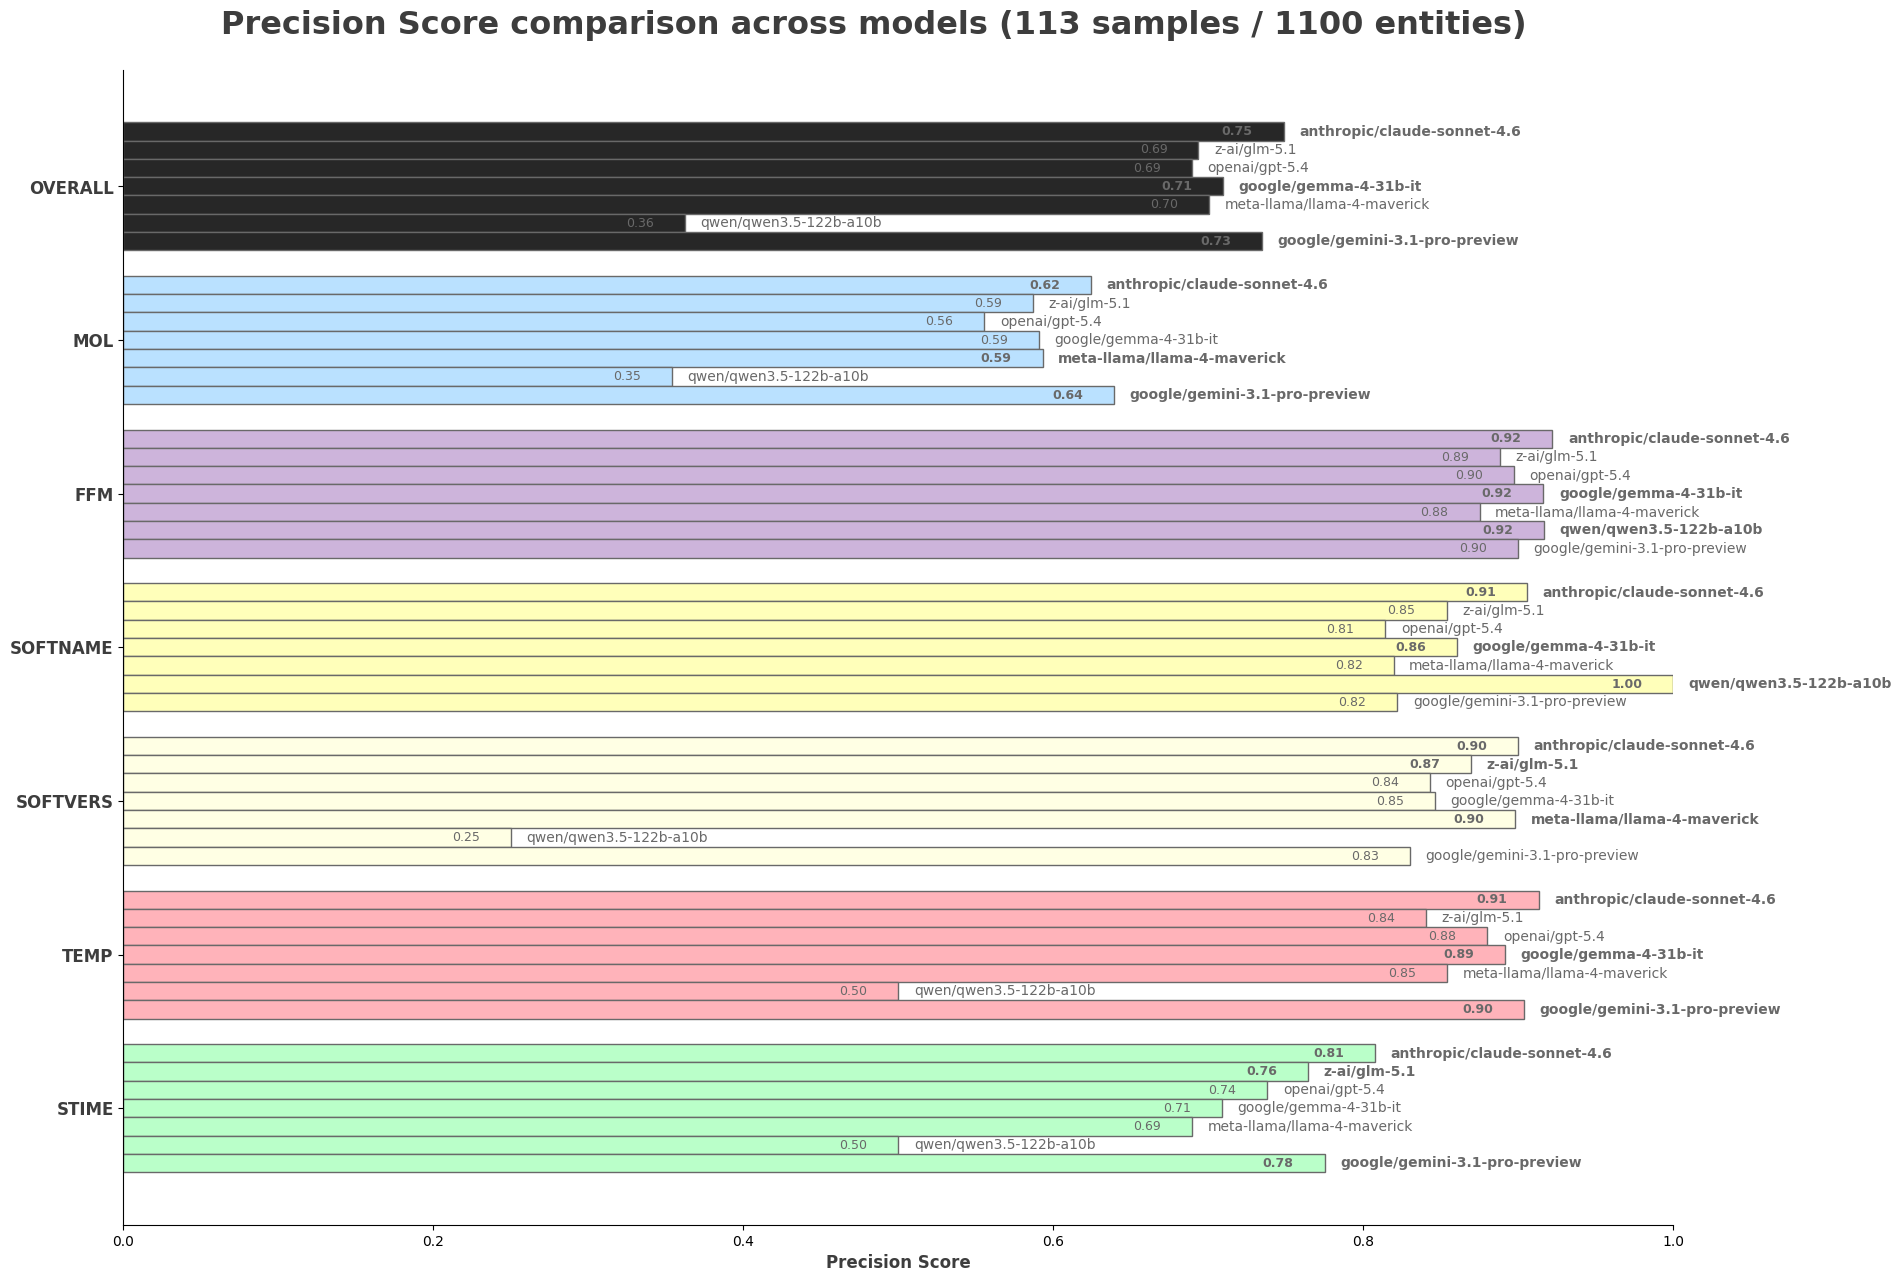

In [15]:
plot_score(
    df=llm_df,
    framework="instructor",
    metric=metric,
    categories=categories,
    models=models,
)

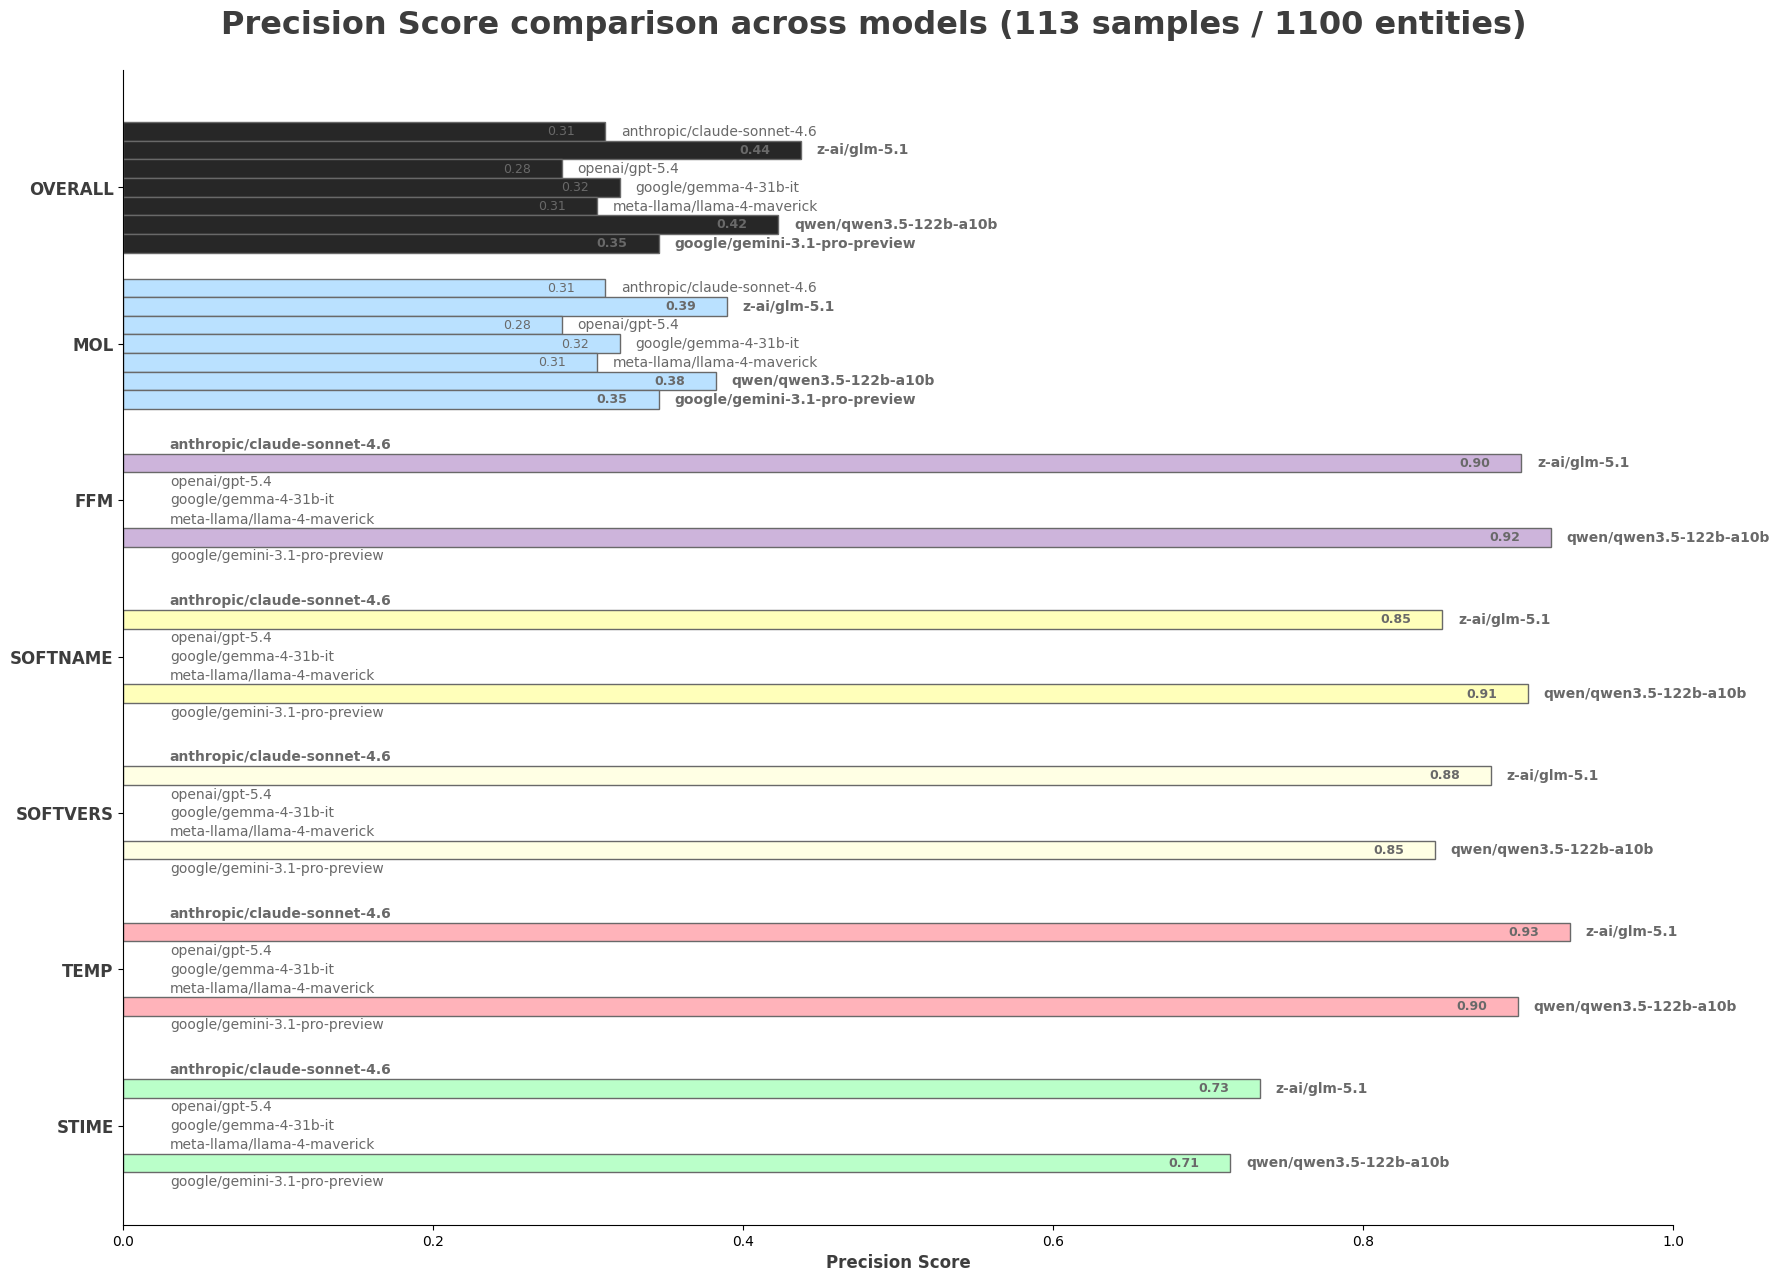

In [16]:
plot_score(
    df=llm_df,
    framework="noframework",
    metric=metric,
    categories=categories,
    models=models,
)


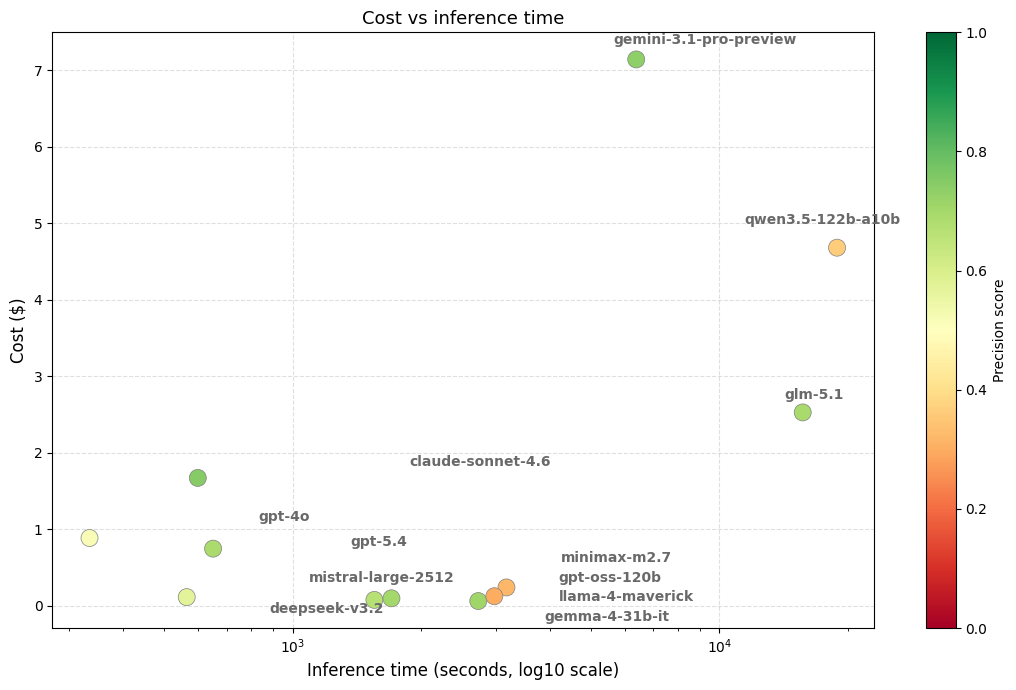

In [17]:
# To add separation proprietary vs open-source models
# squares vs rounds
# color palette more efficient
plot_llm_cost_vs_time(llm_df, framework="instructor")

## **Comparison of GLINER2 Models**

In [18]:
path = Path("../results/gliner/evaluation_stats/grouped_evaluation_metrics.csv")
gliner_df = pd.read_csv(path)
model_names = gliner_df["model_name"].unique()
category_names = gliner_df["category"].unique()
print(f"Models ({len(model_names)}): {', '.join(model_names)}")
print(f"Categories ({len(category_names)}): {', '.join(category_names)}")
gliner_df

Models (4): fastino/gliner2-base-v1, fastino/gliner2-large-v1, results/gliner/models/gliner2-base-v1-finetuned-test-batch-4/best, results/gliner/models/gliner2-large-v1-finetuned-test-batch-4/best
Categories (7): FFM, MOL, SOFTNAME, SOFTVERS, STIME, TEMP, OVERALL


,model_name,framework_name,category,nb_texts_with_category,nb_groundtruth_entities,nb_predicted_entities,pct_correct_format,pct_hallucinations,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,fastino/gliner2-base-v1,noframework,FFM,19,42,34,100.0,0.0,22,12,20,274.210526,209.578947,NaN,NaN,0.647059,0.523810,0.578947,0.617978
1,fastino/gliner2-base-v1,noframework,MOL,21,115,81,100.0,0.0,53,28,62,257.761905,199.333333,NaN,NaN,0.654321,0.460870,0.540816,0.603645
2,fastino/gliner2-base-v1,noframework,SOFTNAME,18,28,28,100.0,0.0,15,13,13,241.166667,203.277778,NaN,NaN,0.535714,0.535714,0.535714,0.535714
3,fastino/gliner2-base-v1,noframework,SOFTVERS,11,14,14,100.0,0.0,4,10,10,225.090909,231.909091,NaN,NaN,0.285714,0.285714,0.285714,0.285714
4,fastino/gliner2-base-v1,noframework,STIME,15,21,25,100.0,0.0,16,9,5,255.533333,216.800000,NaN,NaN,0.640000,0.761905,0.695652,0.661157
5,fastino/gliner2-base-v1,noframework,TEMP,12,14,13,100.0,0.0,12,1,2,267.000000,244.416667,NaN,NaN,0.923077,0.857143,0.888889,0.909091
6,fastino/gliner2-large-v1,noframework,FFM,19,42,32,100.0,0.0,18,14,24,274.210526,231.315789,NaN,NaN,0.562500,0.428571,0.486486,0.529412
7,fastino/gliner2-large-v1,noframework,MOL,21,115,115,100.0,0.0,62,53,53,257.761905,223.476190,NaN,NaN,0.539130,0.539130,0.539130,0.539130
8,fastino/gliner2-large-v1,noframework,SOFTNAME,18,28,28,100.0,0.0,22,6,6,241.166667,217.833333,NaN,NaN,0.785714,0.785714,0.785714,0.785714
9,fastino/gliner2-large-v1,noframework,SOFTVERS,11,14,13,100.0,0.0,10,3,4,225.090909,242.545455,NaN,NaN,0.769231,0.714286,0.740741,0.757576


In [19]:
gliner_df["model_name"] = gliner_df["model_name"].str.replace(
    r".*gliner2-base.*best",
    "fastino/gliner2-base-v1-finetuned",
    regex=True,
)

gliner_df["model_name"] = gliner_df["model_name"].str.replace(
    r".*gliner2-large.*best",
    "fastino/gliner2-large-v1-finetuned",
    regex=True,
)
gliner_df

,model_name,framework_name,category,nb_texts_with_category,nb_groundtruth_entities,nb_predicted_entities,pct_correct_format,pct_hallucinations,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,fastino/gliner2-base-v1,noframework,FFM,19,42,34,100.0,0.0,22,12,20,274.210526,209.578947,NaN,NaN,0.647059,0.523810,0.578947,0.617978
1,fastino/gliner2-base-v1,noframework,MOL,21,115,81,100.0,0.0,53,28,62,257.761905,199.333333,NaN,NaN,0.654321,0.460870,0.540816,0.603645
2,fastino/gliner2-base-v1,noframework,SOFTNAME,18,28,28,100.0,0.0,15,13,13,241.166667,203.277778,NaN,NaN,0.535714,0.535714,0.535714,0.535714
3,fastino/gliner2-base-v1,noframework,SOFTVERS,11,14,14,100.0,0.0,4,10,10,225.090909,231.909091,NaN,NaN,0.285714,0.285714,0.285714,0.285714
4,fastino/gliner2-base-v1,noframework,STIME,15,21,25,100.0,0.0,16,9,5,255.533333,216.800000,NaN,NaN,0.640000,0.761905,0.695652,0.661157
5,fastino/gliner2-base-v1,noframework,TEMP,12,14,13,100.0,0.0,12,1,2,267.000000,244.416667,NaN,NaN,0.923077,0.857143,0.888889,0.909091
6,fastino/gliner2-large-v1,noframework,FFM,19,42,32,100.0,0.0,18,14,24,274.210526,231.315789,NaN,NaN,0.562500,0.428571,0.486486,0.529412
7,fastino/gliner2-large-v1,noframework,MOL,21,115,115,100.0,0.0,62,53,53,257.761905,223.476190,NaN,NaN,0.539130,0.539130,0.539130,0.539130
8,fastino/gliner2-large-v1,noframework,SOFTNAME,18,28,28,100.0,0.0,22,6,6,241.166667,217.833333,NaN,NaN,0.785714,0.785714,0.785714,0.785714
9,fastino/gliner2-large-v1,noframework,SOFTVERS,11,14,13,100.0,0.0,10,3,4,225.090909,242.545455,NaN,NaN,0.769231,0.714286,0.740741,0.757576


In [20]:
gliner_df

,model_name,framework_name,category,nb_texts_with_category,nb_groundtruth_entities,nb_predicted_entities,pct_correct_format,pct_hallucinations,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,fastino/gliner2-base-v1,noframework,FFM,19,42,34,100.0,0.0,22,12,20,274.210526,209.578947,NaN,NaN,0.647059,0.523810,0.578947,0.617978
1,fastino/gliner2-base-v1,noframework,MOL,21,115,81,100.0,0.0,53,28,62,257.761905,199.333333,NaN,NaN,0.654321,0.460870,0.540816,0.603645
2,fastino/gliner2-base-v1,noframework,SOFTNAME,18,28,28,100.0,0.0,15,13,13,241.166667,203.277778,NaN,NaN,0.535714,0.535714,0.535714,0.535714
3,fastino/gliner2-base-v1,noframework,SOFTVERS,11,14,14,100.0,0.0,4,10,10,225.090909,231.909091,NaN,NaN,0.285714,0.285714,0.285714,0.285714
4,fastino/gliner2-base-v1,noframework,STIME,15,21,25,100.0,0.0,16,9,5,255.533333,216.800000,NaN,NaN,0.640000,0.761905,0.695652,0.661157
5,fastino/gliner2-base-v1,noframework,TEMP,12,14,13,100.0,0.0,12,1,2,267.000000,244.416667,NaN,NaN,0.923077,0.857143,0.888889,0.909091
6,fastino/gliner2-large-v1,noframework,FFM,19,42,32,100.0,0.0,18,14,24,274.210526,231.315789,NaN,NaN,0.562500,0.428571,0.486486,0.529412
7,fastino/gliner2-large-v1,noframework,MOL,21,115,115,100.0,0.0,62,53,53,257.761905,223.476190,NaN,NaN,0.539130,0.539130,0.539130,0.539130
8,fastino/gliner2-large-v1,noframework,SOFTNAME,18,28,28,100.0,0.0,22,6,6,241.166667,217.833333,NaN,NaN,0.785714,0.785714,0.785714,0.785714
9,fastino/gliner2-large-v1,noframework,SOFTVERS,11,14,13,100.0,0.0,10,3,4,225.090909,242.545455,NaN,NaN,0.769231,0.714286,0.740741,0.757576


In [21]:
# Define parameters for the plot
# Metric to plot ("precision_score", "recall_score", "f1_score", "fbeta_0.5_score")
metric = "precision_score"
# Models
models = [
    "fastino/gliner2-base-v1",
    "fastino/gliner2-large-v1",
    "fastino/gliner2-base-v1-finetuned",
    "fastino/gliner2-large-v1-finetuned",
]

In [22]:
# Categories to plot in this order
categories = ["OVERALL", "MOL", "FFM", "SOFTNAME", "SOFTVERS", "TEMP", "STIME"]
# More focused categories
# categories = ["OVERALL", "MOL"]

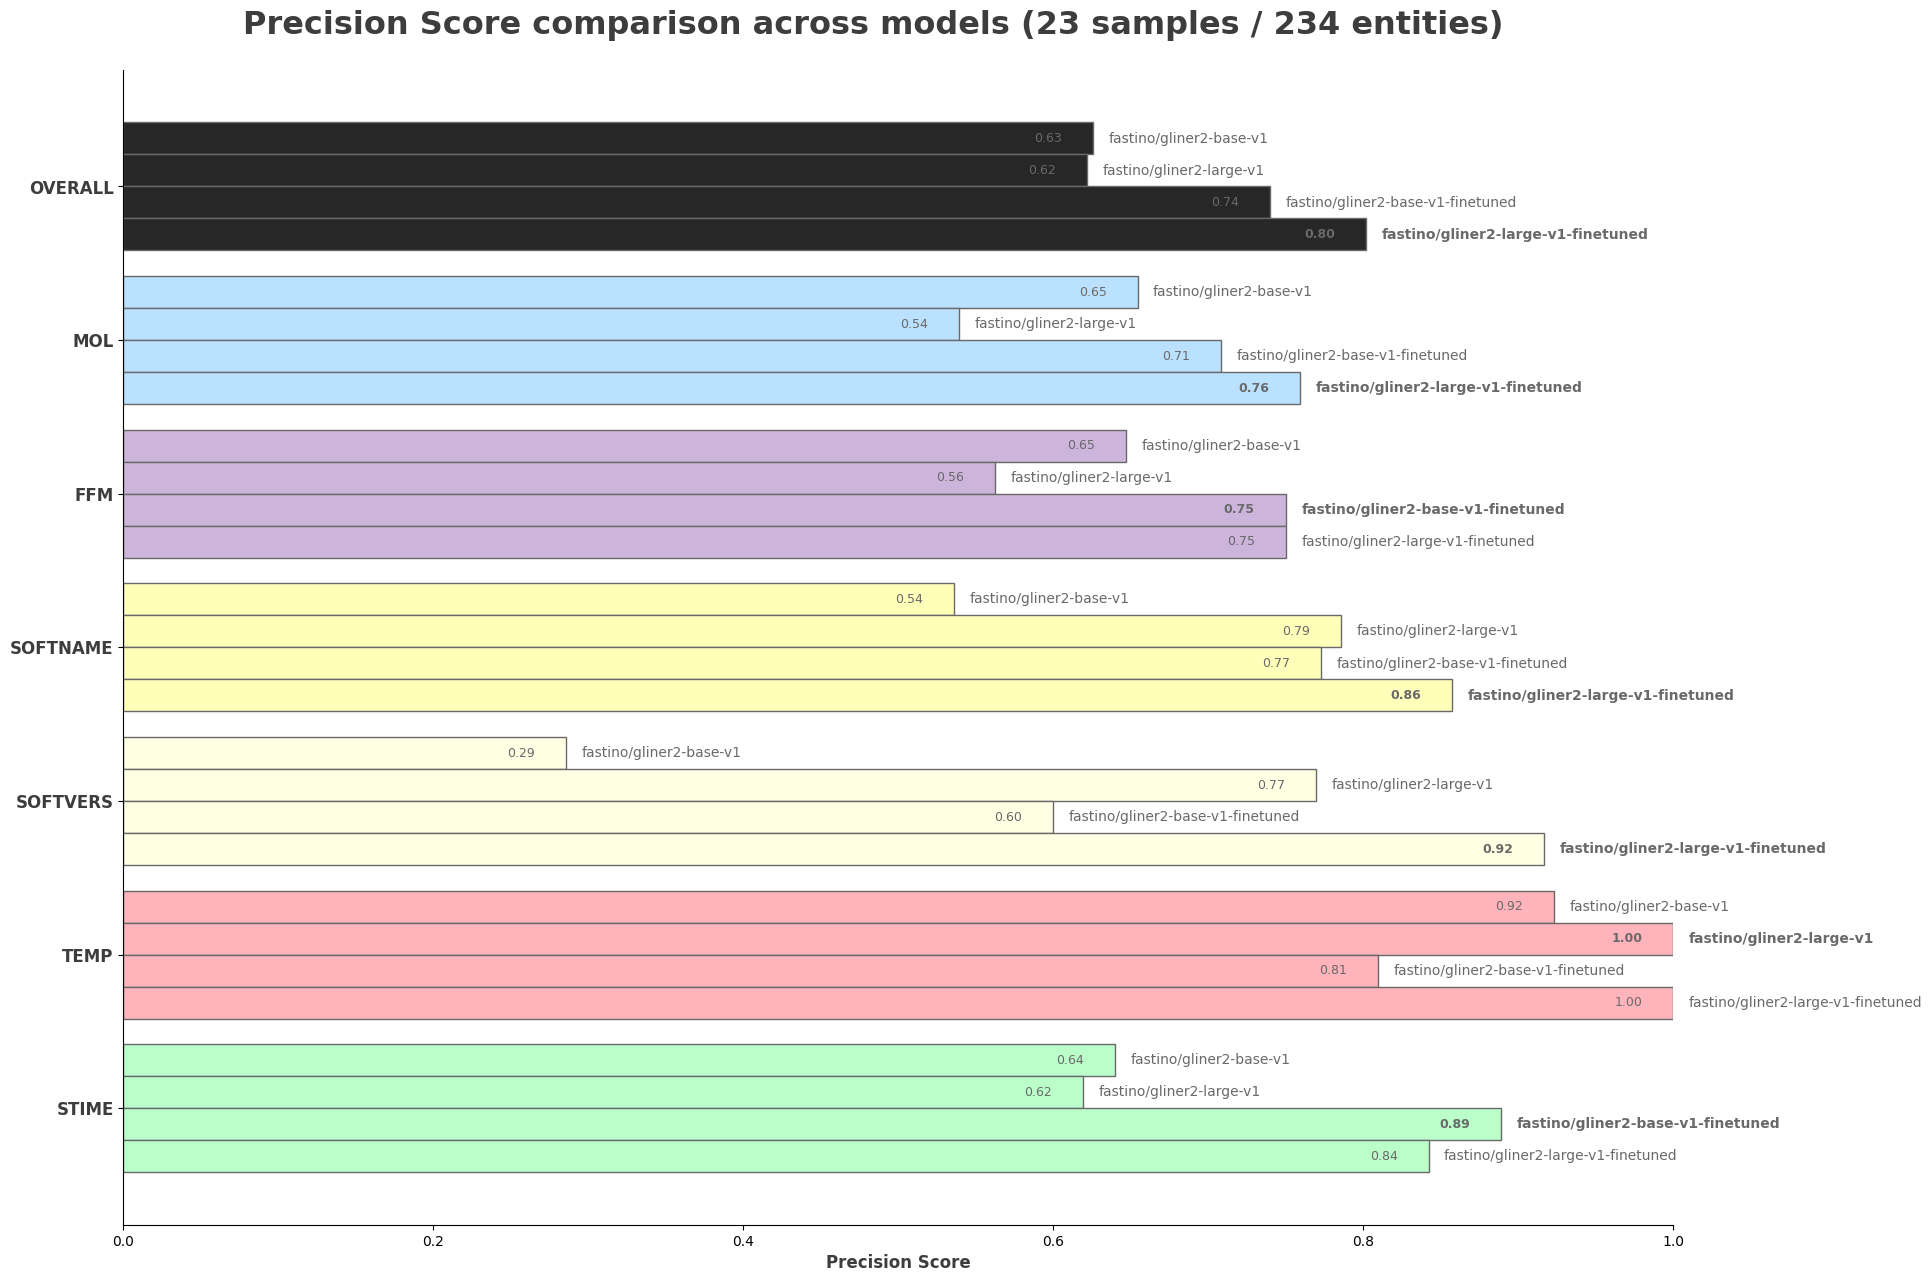

In [23]:
plot_score(
    df=gliner_df,
    framework="noframework",
    metric=metric,
    categories=categories,
    models=models,
    top_k=1,
)

## **Comparison of GLINER2 vs LLM Models**

In [24]:
# Concat all evaluation results
gliner_df["framework_name"] = None
eval_df = pd.concat([llm_df, gliner_df], ignore_index=True)
eval_df

,model_name,framework_name,category,nb_texts_with_category,nb_groundtruth_entities,nb_predicted_entities,pct_correct_format,pct_hallucinations,true_positives,false_positives,false_negatives,average_input_tokens,average_output_tokens,total_cost_usd,total_inference_time_sec,precision_score,recall_score,f1_score,fbeta_0.5_score
0,anthropic/claude-sonnet-4.6,instructor,FFM,83,179,141,100.0,0.0,130,11,49,3771.928571,227.845238,NaN,NaN,0.921986,0.726257,0.812500,0.874832
1,anthropic/claude-sonnet-4.6,instructor,MOL,110,566,519,100.0,0.0,324,195,242,3768.339286,216.428571,NaN,NaN,0.624277,0.572438,0.597235,0.613172
2,anthropic/claude-sonnet-4.6,instructor,SOFTNAME,73,125,106,100.0,0.0,96,10,29,3782.697368,227.407895,NaN,NaN,0.905660,0.768000,0.831169,0.874317
3,anthropic/claude-sonnet-4.6,instructor,SOFTVERS,46,52,40,100.0,0.0,36,4,16,3802.702128,243.893617,NaN,NaN,0.900000,0.692308,0.782609,0.849057
4,anthropic/claude-sonnet-4.6,instructor,STIME,68,98,104,100.0,0.0,84,20,14,3797.318841,241.594203,NaN,NaN,0.807692,0.857143,0.831683,0.817121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,fastino/gliner2-large-v1-finetuned,None,TEMP,13,17,15,100.0,0.0,15,0,2,221.076923,218.615385,NaN,NaN,1.000000,0.882353,0.937500,0.974026
192,fastino/gliner2-base-v1,None,OVERALL,23,234,195,100.0,0.0,122,73,112,261.217391,190.782609,0.0,5.401977,0.625641,0.521368,0.568765,0.601578
193,fastino/gliner2-large-v1,None,OVERALL,23,234,222,100.0,0.0,138,84,96,261.217391,212.260870,0.0,15.629170,0.621622,0.589744,0.605263,0.614973
194,fastino/gliner2-base-v1-finetuned,None,OVERALL,23,211,200,100.0,0.0,148,52,63,230.304348,191.521739,0.0,4.385949,0.740000,0.701422,0.720195,0.731949


In [25]:
# Define parameters for the plot
# Framework for LLMs ("noframework", "instructor", "pydanticai")
framework = "instructor"
# Metric to plot ("precision_score", "recall_score", "f1_score", "fbeta_0.5_score")
metric = "precision_score"
# Models
models = [
    # "openai/gpt-4o",
    "anthropic/claude-sonnet-4.6",
    # "z-ai/glm-5.1",
    # "openai/gpt-5.4",
    # "deepseek/deepseek-v3.2",
    "google/gemma-4-31b-it",
    # "meta-llama/llama-4-maverick",
    # "nvidia/nemotron-3-super-120b-a12b",
    # "mistralai/mistral-large-2512",
    # "minimax/minimax-m2.7",
    # "openai/gpt-oss-120b",
    # "qwen/qwen3.5-122b-a10b",
    # "google/gemini-3.1-pro-preview",
    # "fastino/gliner2-base-v1",
    "fastino/gliner2-large-v1-finetuned",
]

In [26]:
# Categories to plot in this order
# categories = ["OVERALL", "MOL", "FFM", "SOFTNAME", "SOFTVERS", "TEMP", "STIME"]
# More focused categories
categories = ["OVERALL", "MOL"]

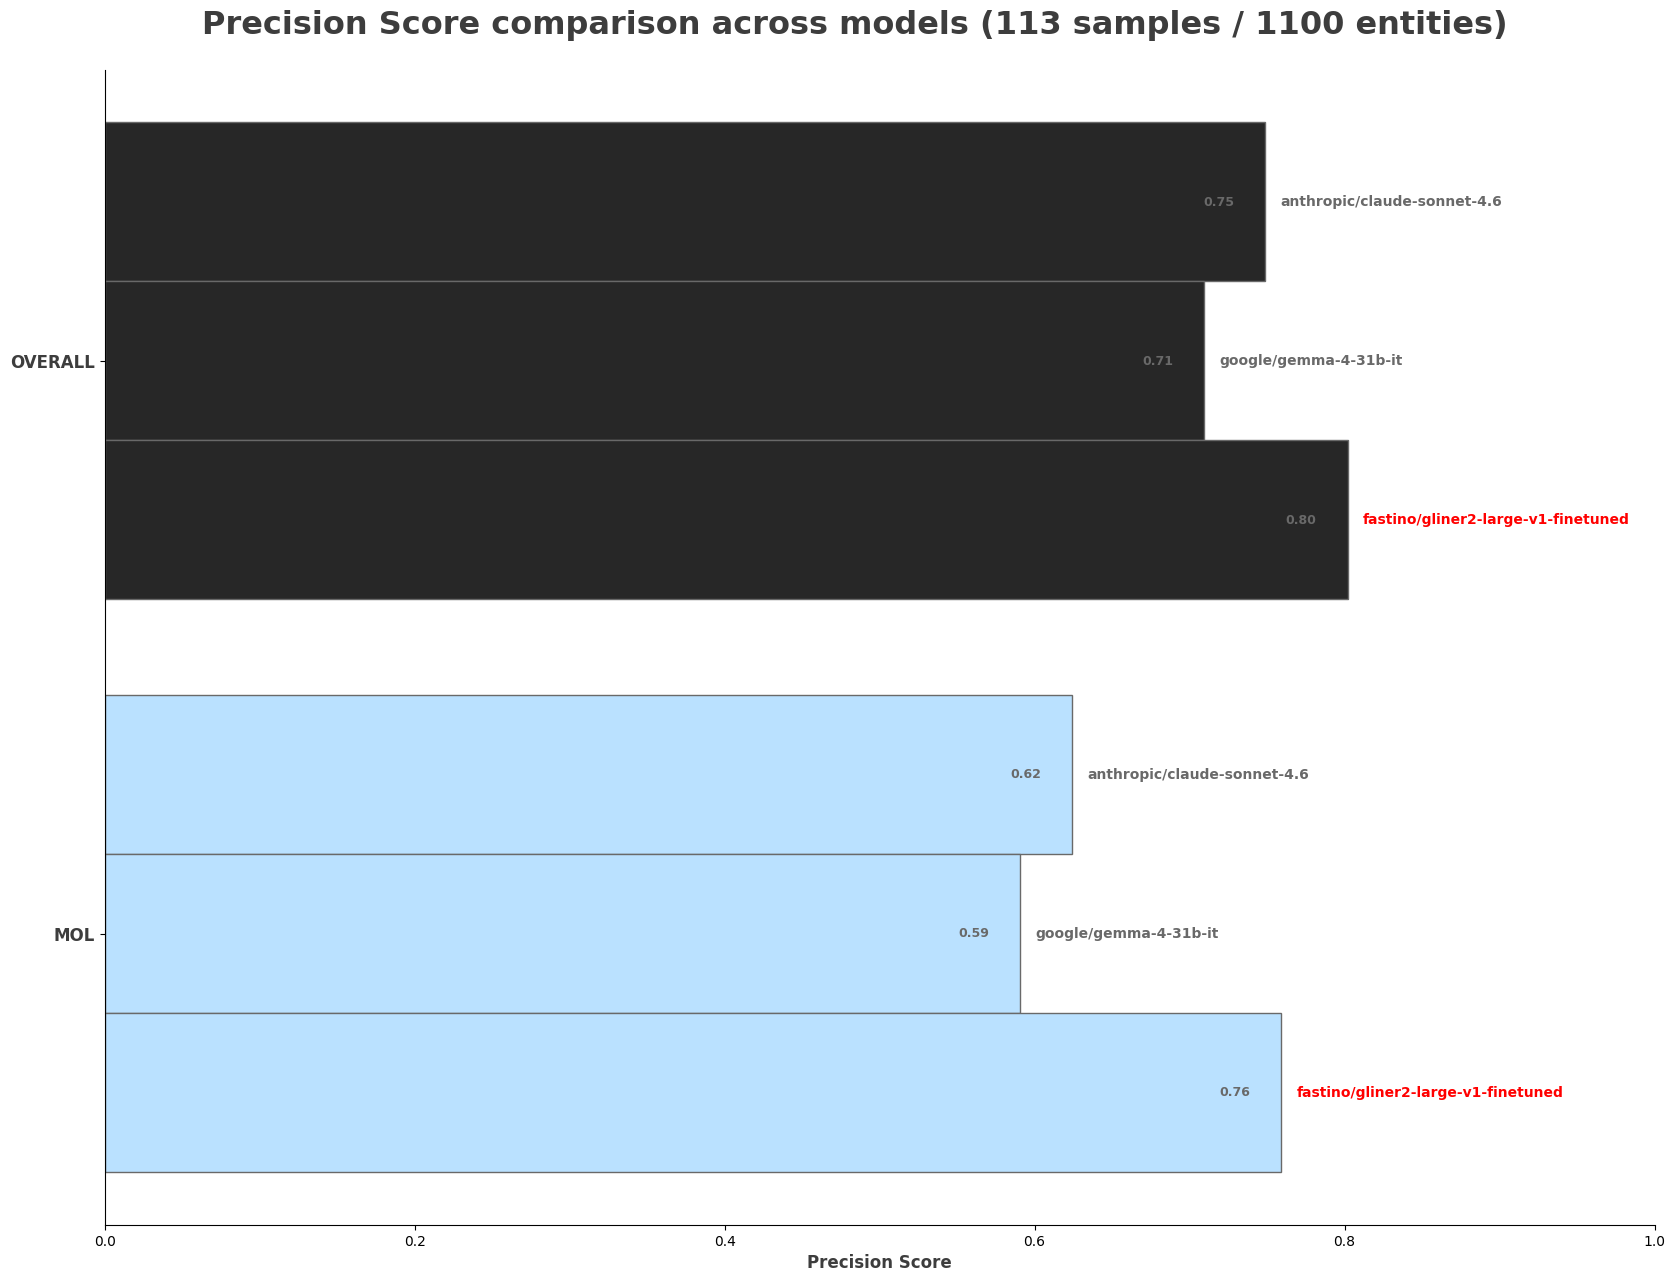

In [27]:
plot_score(
    df=eval_df,
    framework=framework,
    metric=metric,
    categories=categories,
    models=models,
    top_k=3,
)